# TEM11 fit

Fit one camera frame to a translated, isotropically scaled TEM11 intensity pattern.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter, zoom
from scipy.optimize import minimize
from scipy.signal import fftconvolve



PYRAMID_FACTORS = (8, 4, 1)
COARSE_WAIST_SAMPLES = 41
KEEP_CANDIDATES = 3
MAXITER_PER_COARSE_LEVEL = 30
MAXITER_FULL_RES = 12
MIN_WAIST_FRACTION = 0.03
MAX_WAIST_FRACTION = 0.60


In [2]:
def tem11_intensity(shape, center_x, center_y, waist_px):
    """Peak-normalized TEM11 intensity on an image grid."""
    height, width = shape
    y, x = np.indices((height, width), dtype=np.float64)
    dx = (x - center_x) / waist_px
    dy = (y - center_y) / waist_px
    intensity = dx**2 * dy**2 * np.exp(-2.0 * (dx**2 + dy**2))
    return intensity / intensity.max()


def image_statistics(image):
    mean = float(image.mean())
    return {
        'count': image.size,
        'mean': mean,
        'centered_sum_squares': float(np.sum((image - mean)**2)),
    }


def template_rss(image, template, statistics):
    """Fit non-negative gain/background and return RSS without a residual allocation."""
    template_mean = template.mean()
    template_sum_squares = np.sum((template - template_mean)**2)
    covariance = np.sum(image * template) - (
        statistics['count'] * statistics['mean'] * template_mean
    )
    if template_sum_squares <= 0 or covariance <= 0:
        return statistics['centered_sum_squares'], 0.0, statistics['mean']

    gain = covariance / template_sum_squares
    background = statistics['mean'] - gain * template_mean
    rss = statistics['centered_sum_squares'] - covariance**2 / template_sum_squares
    return float(max(rss, 0.0)), float(gain), float(background)


def downsample_for_search(image, factor):
    if factor == 1:
        return image
    return zoom(
        gaussian_filter(image, sigma=factor / 2.0),
        zoom=1.0 / factor,
        order=1,
        prefilter=False,
    )


def keep_best(candidates, count=KEEP_CANDIDATES):
    return sorted(candidates, key=lambda candidate: candidate['rss'])[:count]


def coarse_search(image, factor, waist_values_full_px):
    """Search all translations by FFT for each candidate TEM11 waist."""
    height, width = image.shape
    statistics = image_statistics(image)
    image_centered = image - statistics['mean']
    candidates = []

    for waist_full_px in waist_values_full_px:
        waist = waist_full_px / factor
        template = tem11_intensity(
            image.shape, (width - 1) / 2, (height - 1) / 2, waist
        )
        correlation = fftconvolve(
            image_centered, (template - template.mean())[::-1, ::-1], mode='same'
        )
        center_y, center_x = np.unravel_index(np.argmax(correlation), correlation.shape)
        template = tem11_intensity(image.shape, center_x, center_y, waist)
        rss, _, _ = template_rss(image, template, statistics)
        candidates.append(
            {'params': np.array([center_x, center_y, waist]), 'rss': rss}
        )

    return keep_best(candidates)


def refine_candidates(image, factor, starts, waist_bounds_full_px, count, record_history=False):
    height, width = image.shape
    waist_min, waist_max = (bound / factor for bound in waist_bounds_full_px)
    bounds = [(0, width - 1), (0, height - 1), (waist_min, waist_max)]
    statistics = image_statistics(image)
    candidates = []

    def objective(params):
        return template_rss(image, tem11_intensity(image.shape, *params), statistics)[0]

    for start in starts:
        history = [objective(start)]

        def record(params):
            history.append(objective(params))

        result = minimize(
            objective,
            x0=start,
            method='L-BFGS-B',
            bounds=bounds,
            callback=record if record_history else None,
            options={
                'maxiter': MAXITER_FULL_RES if factor == 1 else MAXITER_PER_COARSE_LEVEL
            },
        )
        if record_history and history[-1] != result.fun:
            history.append(float(result.fun))
        candidates.append(
            {'params': result.x, 'rss': float(result.fun), 'history': history}
        )

    return keep_best(candidates, count=count)


def fit_tem11(frame):
    frame = np.asarray(frame, dtype=np.float64)
    if frame.ndim != 2:
        raise ValueError(f'Expected a monochrome 2D frame, got shape {frame.shape}.')

    waist_bounds_full_px = (
        min(frame.shape) * MIN_WAIST_FRACTION,
        min(frame.shape) * MAX_WAIST_FRACTION,
    )
    waist_values_full_px = np.linspace(*waist_bounds_full_px, COARSE_WAIST_SAMPLES)
    pyramid = [(factor, downsample_for_search(frame, factor)) for factor in PYRAMID_FACTORS]

    previous_factor, coarse_image = pyramid[0]
    candidates = coarse_search(coarse_image, previous_factor, waist_values_full_px)

    for factor, level_image in pyramid[1:]:
        starts = [
            candidate['params'] * (previous_factor / factor)
            for candidate in candidates
        ]
        candidates = refine_candidates(
            level_image,
            factor,
            starts,
            waist_bounds_full_px,
            count=1 if factor == 1 else KEEP_CANDIDATES,
            record_history=factor == 1,
        )
        previous_factor = factor

    center_x, center_y, waist_px = candidates[0]['params']
    template = tem11_intensity(frame.shape, center_x, center_y, waist_px)
    rss, gain, background = template_rss(frame, template, image_statistics(frame))
    return {
        'center_x_px': float(center_x),
        'center_y_px': float(center_y),
        'waist_px': float(waist_px),
        'gain': gain,
        'background': background,
        'rss': rss,
        'convergence_rss': candidates[0]['history'],
    }


def load_tiff(path):
    with Image.open(path) as image_file:
        frame = np.asarray(image_file)
    if frame.ndim == 3:
        frame = frame[..., 0]
    return np.asarray(frame, dtype=np.float64)


In [3]:
from io import BytesIO

import ipywidgets as widgets
from IPython.display import display
from matplotlib.backends.backend_agg import FigureCanvasAgg
# Change this to the camera TIFF frame you want to fit.
PATH = Path('../output/TEM TEST/TEM_11_100iterations_seed0_GS/Gaussian_050.tif')
frame = load_tiff(PATH)
fit = fit_tem11(frame)
template = tem11_intensity(
    frame.shape, fit['center_x_px'], fit['center_y_px'], fit['waist_px']
)
model = fit['background'] + fit['gain'] * template

def figure_as_png(figure):
    buffer = BytesIO()
    FigureCanvasAgg(figure).print_png(buffer)
    plt.close(figure)
    return buffer.getvalue()

convergence_figure, convergence_axis = plt.subplots(figsize=(7, 5))
convergence_axis.semilogy(fit['convergence_rss'], marker='o')
convergence_axis.set_title('Full-resolution convergence')
convergence_axis.set_xlabel('L-BFGS-B iteration')
convergence_axis.set_ylabel('RSS')
convergence_axis.grid(True, which='both', alpha=0.3)
convergence_png = figure_as_png(convergence_figure)

# Camera-only structure is red, fitted-only structure is blue, and agreement is magenta.
vmin, vmax = np.percentile(frame, (1, 99.9))
def display_scale(image):
    return np.clip((image - vmin) / max(vmax - vmin, 1.0), 0.0, 1.0)

show_camera = widgets.Checkbox(value=True, description='Camera (red)')
show_fit = widgets.Checkbox(value=True, description='Fitted TEM11 (blue)')
overlay_widget = widgets.Image(format='png')

def update_overlay(change=None):
    overlay = np.zeros((*frame.shape, 3), dtype=np.float64)
    if show_camera.value:
        overlay[..., 0] = display_scale(frame)
    if show_fit.value:
        overlay[..., 2] = display_scale(model)

    overlay_figure, overlay_axis = plt.subplots(figsize=(8, 7))
    overlay_axis.imshow(overlay)
    overlay_axis.plot(fit['center_x_px'], fit['center_y_px'], 'w+', ms=12, mew=1.5)
    overlay_axis.set_title('Camera red / fitted TEM11 blue')
    overlay_axis.set_axis_off()
    overlay_widget.value = figure_as_png(overlay_figure)

show_camera.observe(update_overlay, names='value')
show_fit.observe(update_overlay, names='value')
update_overlay()

single_fit_view = widgets.VBox([
    widgets.HTML(f'<b>RSS:</b> {fit["rss"]:.6e}'),
    widgets.Image(value=convergence_png, format='png'),
    widgets.HBox([show_camera, show_fit]),
    overlay_widget,
])
display(single_fit_view)


In [4]:
# Fit all Gaussian-input-beam experiments and plot raw RSS against beam width.
import re
from IPython.display import display
from tqdm.auto import tqdm

GAUSSIAN_DIR = Path('../output/TEM TEST/TEM_11_100iterations_seed0_GS')
gaussian_name = re.compile(r'^Gaussian[ _](\d+)\.tiff?$', re.IGNORECASE)

gaussian_files = []
for path in sorted(list(GAUSSIAN_DIR.rglob('*.tif')) + list(GAUSSIAN_DIR.rglob('*.tiff'))):
    match = gaussian_name.match(path.name)
    if match:
        gaussian_files.append((int(match.group(1)), path))

if not gaussian_files:
    raise FileNotFoundError(f'No Gaussian_###.tif or Gaussian ###.tif files found in {GAUSSIAN_DIR}')

gaussian_results = []
for width_px, path in tqdm(sorted(gaussian_files), desc='Gaussian beam widths', unit='image'):
    tqdm.write(f'Fitting input-beam width {width_px}: {path.name}')
    result = fit_tem11(load_tiff(path))
    gaussian_results.append({'width_px': width_px, 'rss': result['rss'], 'path': path})


Gaussian beam widths:   0%|          | 0/12 [00:00<?, ?image/s]

Fitting input-beam width 50: Gaussian_050.tif
Fitting input-beam width 70: Gaussian_070.tif
Fitting input-beam width 90: Gaussian_090.tif
Fitting input-beam width 100: Gaussian_100.tif
Fitting input-beam width 120: Gaussian_120.tif
Fitting input-beam width 140: Gaussian_140.tif
Fitting input-beam width 160: Gaussian_160.tif
Fitting input-beam width 180: Gaussian_180.tif
Fitting input-beam width 200: Gaussian_200.tif
Fitting input-beam width 220: Gaussian_220.tif
Fitting input-beam width 250: Gaussian_250.tif
Fitting input-beam width 300: Gaussian 300.tif


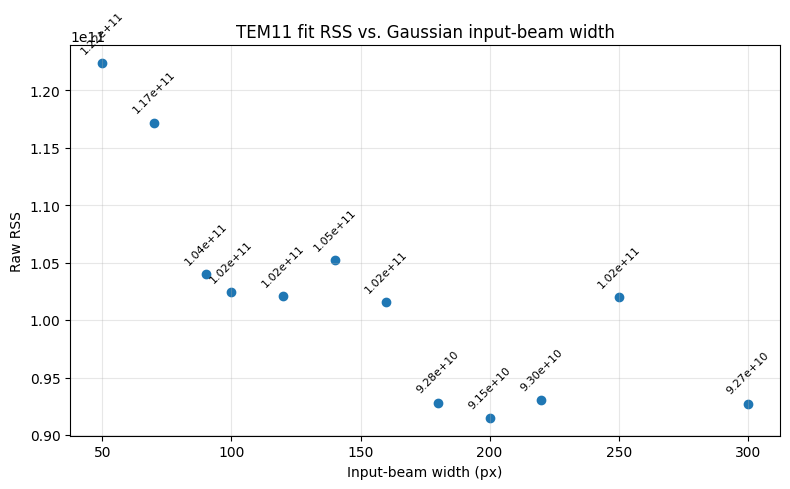

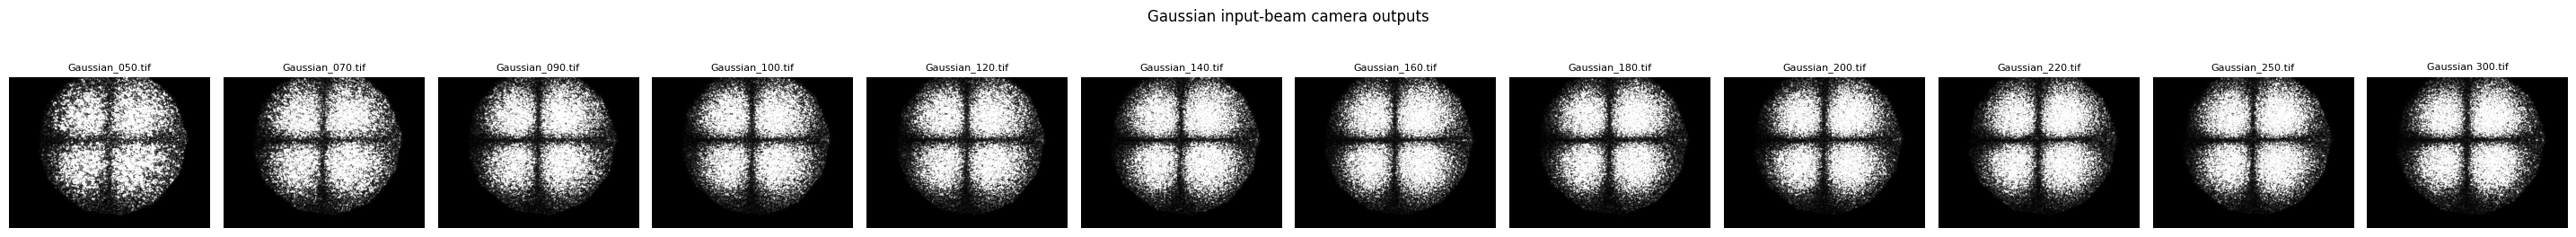

In [5]:

gaussian_results.sort(key=lambda item: item['width_px'])
gaussian_widths = [item['width_px'] for item in gaussian_results]
gaussian_rss = [item['rss'] for item in gaussian_results]

figure, axis = plt.subplots(figsize=(8, 5))
axis.scatter(gaussian_widths, gaussian_rss, marker='o')
axis.set_title('TEM11 fit RSS vs. Gaussian input-beam width')
axis.set_xlabel('Input-beam width (px)')
axis.set_ylabel('Raw RSS')
axis.grid(True, alpha=0.3)
for width_px, rss in zip(gaussian_widths, gaussian_rss):
    axis.annotate(f'{rss:.2e}', (width_px, rss), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, rotation=45)
figure.tight_layout()
display(figure)
plt.close(figure)

# Camera frames only: each image is independently percentile-scaled for visibility.
frame_count = len(gaussian_results)
figure, axes = plt.subplots(1, frame_count, figsize=(2.4 * frame_count, 3.2), squeeze=False)
for axis, item in zip(axes[0], gaussian_results):
    camera_frame = load_tiff(item['path'])
    vmin, vmax = np.percentile(camera_frame, (1, 99.9))
    axis.imshow(camera_frame, cmap='gray', vmin=vmin, vmax=max(vmax, vmin + 1))
    axis.set_title(item['path'].name, fontsize=8)
    axis.set_axis_off()
figure.suptitle('Gaussian input-beam camera outputs', y=0.95)
figure.tight_layout()
display(figure)
plt.close(figure)


In [6]:
# Fit all uniform-input-beam GS variants and compare their raw RSS values.
from tqdm.auto import tqdm

UNIFORM_BEAM_DIR = Path('../output/TEM TEST/TEM_100iterations_seed0_Uniform beam')
uniform_beam_files = sorted(list(UNIFORM_BEAM_DIR.rglob('*.tif')) + list(UNIFORM_BEAM_DIR.rglob('*.tiff')))

if not uniform_beam_files:
    raise FileNotFoundError(f'No TIFF files found in {UNIFORM_BEAM_DIR}')

uniform_beam_results = []
for path in tqdm(uniform_beam_files, desc='Uniform-beam variants', unit='image'):
    tqdm.write(f'Fitting {path.name}')
    result = fit_tem11(load_tiff(path))
    uniform_beam_results.append({'algorithm': path.stem, 'rss': result['rss'], 'path': path})



Uniform-beam variants:   0%|          | 0/6 [00:00<?, ?image/s]

Fitting GS.tif
Fitting TEM_WGS_LEONARDO.tif
Fitting WGS-KIM.tif
Fitting WGS-Nogrette.tif
Fitting WGS-WU.tif
Fitting WGS_tanh.tif


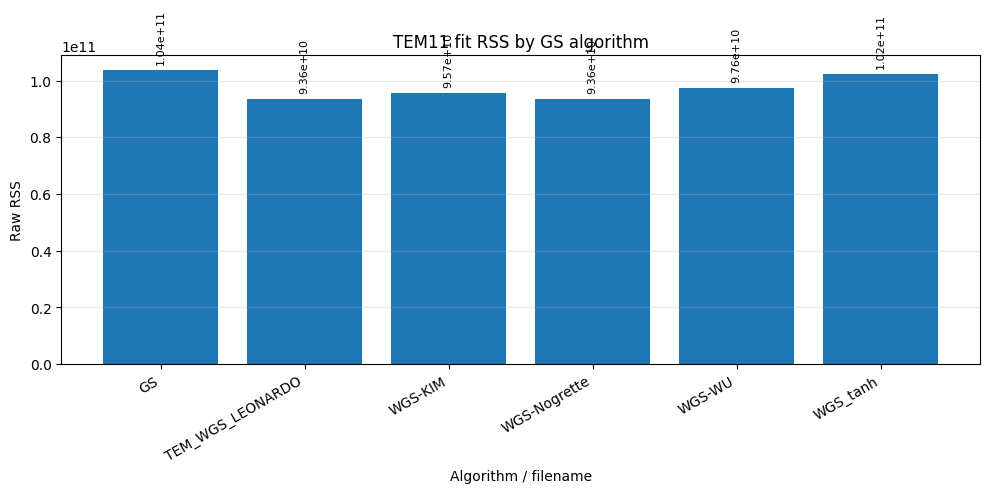

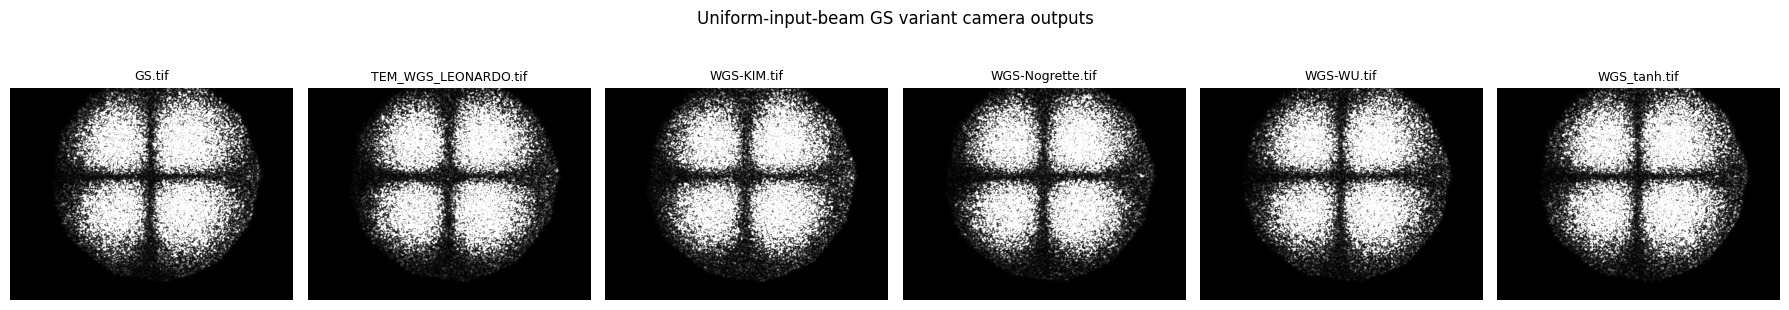

In [7]:

algorithm_names = [item['algorithm'] for item in uniform_beam_results]
algorithm_rss = [item['rss'] for item in uniform_beam_results]

figure, axis = plt.subplots(figsize=(10, 5))
bars = axis.bar(algorithm_names, algorithm_rss)
axis.set_title('TEM11 fit RSS by GS algorithm')
axis.set_xlabel('Algorithm / filename')
axis.set_ylabel('Raw RSS')
axis.tick_params(axis='x', rotation=30)
for label in axis.get_xticklabels():
    label.set_ha('right')
for bar, rss in zip(bars, algorithm_rss):
    axis.annotate(f'{rss:.2e}', (bar.get_x() + bar.get_width() / 2, bar.get_height()), xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=8, rotation=90)
axis.grid(axis='y', alpha=0.3)
figure.tight_layout()
display(figure)
plt.close(figure)

# Camera frames only: each image is independently percentile-scaled for visibility.
frame_count = len(uniform_beam_results)
figure, axes = plt.subplots(1, frame_count, figsize=(3 * frame_count, 4), squeeze=False)
for axis, item in zip(axes[0], uniform_beam_results):
    camera_frame = load_tiff(item['path'])
    vmin, vmax = np.percentile(camera_frame, (1, 99.9))
    axis.imshow(camera_frame, cmap='gray', vmin=vmin, vmax=max(vmax, vmin + 1))
    axis.set_title(item['path'].name, fontsize=9)
    axis.set_axis_off()
figure.suptitle('Uniform-input-beam GS variant camera outputs', y=0.92)
figure.tight_layout()
display(figure)
plt.close(figure)
